# 06 Predictive Billing Exception Risk Model

This notebook adds a predictive analytics layer to the PG&E-style Utility Operations and Meter-to-Cash Analytics project.

The goal is to predict which account-cycle records are at higher risk of creating a billing exception before the billing cycle is finalized.

This extends the project from descriptive analytics into operational risk scoring:

- Power BI dashboard: What happened?
- Predictive model: Which accounts may need attention next?

## 1. Modeling Objective

The target variable is `billing_exception_flag`.

- `1` = the account-cycle had a billing exception
- `0` = the account-cycle did not have a billing exception

The model is designed to support proactive billing operations by identifying account-cycle records that may need review before billing is finalized.

To avoid target leakage, the model does not use fields that directly reveal the exception outcome, such as exception type, exception severity, bill status, or post-resolution fields.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
# Define project paths
PROJECT_ROOT = Path("..")
SYNTHETIC_DIR = PROJECT_ROOT / "data" / "synthetic"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ML_DIR = PROJECT_ROOT / "data" / "ml"

ML_DIR.mkdir(parents=True, exist_ok=True)

print("Synthetic data directory:", SYNTHETIC_DIR.resolve())
print("ML output directory:", ML_DIR.resolve())

Synthetic data directory: C:\Users\Chris\Documents\PGandE\data\synthetic
ML output directory: C:\Users\Chris\Documents\PGandE\data\ml


## 2. Load Synthetic Meter-to-Cash Tables

The model uses the synthetic operational tables created in Notebook 2. These tables represent customers, service accounts, meters, meter reads, bills, billing exceptions, service requests, billing cycles, and rate plans.

The predictive dataset will be built at the account-cycle level.

In [3]:
# Load synthetic Meter-to-Cash tables
customers = pd.read_csv(SYNTHETIC_DIR / "customers.csv")
service_accounts = pd.read_csv(SYNTHETIC_DIR / "service_accounts.csv")
meters = pd.read_csv(SYNTHETIC_DIR / "meters.csv")
meter_reads = pd.read_csv(SYNTHETIC_DIR / "meter_reads.csv")
bills = pd.read_csv(SYNTHETIC_DIR / "bills.csv")
billing_exceptions = pd.read_csv(SYNTHETIC_DIR / "billing_exceptions.csv")
service_requests = pd.read_csv(SYNTHETIC_DIR / "service_requests.csv")
billing_cycles = pd.read_csv(SYNTHETIC_DIR / "billing_cycles.csv")
rate_plans = pd.read_csv(SYNTHETIC_DIR / "rate_plans.csv")

tables = {
    "customers": customers,
    "service_accounts": service_accounts,
    "meters": meters,
    "meter_reads": meter_reads,
    "bills": bills,
    "billing_exceptions": billing_exceptions,
    "service_requests": service_requests,
    "billing_cycles": billing_cycles,
    "rate_plans": rate_plans
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} columns")

customers: 5,000 rows, 5 columns
service_accounts: 5,000 rows, 8 columns
meters: 5,000 rows, 5 columns
meter_reads: 60,000 rows, 9 columns
bills: 60,000 rows, 13 columns
billing_exceptions: 5,403 rows, 12 columns
service_requests: 3,000 rows, 13 columns
billing_cycles: 12 rows, 5 columns
rate_plans: 7 rows, 8 columns


## 3. Inspect Table Schemas

Before building the modeling dataset, inspect the available columns in each synthetic table.

This ensures the feature engineering step uses the correct account, meter, billing cycle, meter read, bill, exception, and service request fields.

In [4]:
# Inspect columns in each table
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print("-" * len(name))
    print(df.columns.tolist())


CUSTOMERS
---------
['customer_id', 'customer_segment', 'county', 'customer_status', 'customer_start_date']

SERVICE_ACCOUNTS
----------------
['account_id', 'customer_id', 'premise_id', 'service_type', 'customer_segment', 'county', 'account_status', 'rate_plan_id']

METERS
------
['meter_id', 'account_id', 'meter_type', 'install_date', 'meter_status']

METER_READS
-----------
['read_id', 'meter_id', 'account_id', 'billing_cycle_id', 'read_date', 'customer_segment', 'county', 'kwh_usage', 'read_status']

BILLS
-----
['bill_id', 'account_id', 'customer_id', 'premise_id', 'billing_cycle_id', 'bill_generation_date', 'bill_due_date', 'customer_segment', 'county', 'rate_plan_id', 'kwh_usage', 'bill_amount', 'bill_status']

BILLING_EXCEPTIONS
------------------
['exception_id', 'bill_id', 'account_id', 'customer_id', 'billing_cycle_id', 'customer_segment', 'county', 'exception_type', 'severity', 'created_date', 'resolved_date', 'resolution_status']

SERVICE_REQUESTS
----------------
['reque

## 4. Build Account-Cycle Modeling Dataset

The model is built at the account-cycle level. Each row represents one account in one billing cycle.

The base table is `meter_reads`, because each account-cycle has a meter read record that is available before billing is finalized.

The target variable is created from `billing_exceptions`:

- `billing_exception_flag = 1` if an account-cycle appears in the billing exceptions table
- `billing_exception_flag = 0` otherwise

Features are joined from service accounts, meters, billing cycles, rate plans, and service requests.

In [5]:
# Start with account-cycle meter read records
model_df = meter_reads.copy()

print("Base meter read records:", model_df.shape)
model_df.head()

Base meter read records: (60000, 9)


,read_id,meter_id,account_id,billing_cycle_id,read_date,customer_segment,county,kwh_usage,read_status
0,READ00000001,MTR000001,ACCT000001,2024-01,2024-01-31,Residential,KERN,403.18,Valid
1,READ00000002,MTR000001,ACCT000001,2024-02,2024-02-29,Residential,KERN,327.38,Valid
2,READ00000003,MTR000001,ACCT000001,2024-03,2024-03-31,Residential,KERN,282.50,Valid
3,READ00000004,MTR000001,ACCT000001,2024-04,2024-04-30,Residential,KERN,414.88,Valid
4,READ00000005,MTR000001,ACCT000001,2024-05,2024-05-31,Residential,KERN,419.60,Valid


In [6]:
# Create target variable from billing exceptions
exception_keys = billing_exceptions[["account_id", "billing_cycle_id"]].drop_duplicates()
exception_keys["billing_exception_flag"] = 1

model_df = model_df.merge(
    exception_keys,
    on=["account_id", "billing_cycle_id"],
    how="left"
)

model_df["billing_exception_flag"] = model_df["billing_exception_flag"].fillna(0).astype(int)

print("Model dataset after target creation:", model_df.shape)
print(model_df["billing_exception_flag"].value_counts())
print(model_df["billing_exception_flag"].value_counts(normalize=True).round(4))

Model dataset after target creation: (60000, 10)
billing_exception_flag
0    54597
1     5403
Name: count, dtype: int64
billing_exception_flag
0    0.91
1    0.09
Name: proportion, dtype: float64


In [7]:
# Join service account features
account_features = service_accounts[
    [
        "account_id",
        "premise_id",
        "service_type",
        "customer_segment",
        "county",
        "account_status",
        "rate_plan_id"
    ]
].copy()

# Avoid duplicate customer_segment/county from meter_reads by dropping before merge
model_df = model_df.drop(columns=["customer_segment", "county"], errors="ignore")

model_df = model_df.merge(
    account_features,
    on="account_id",
    how="left"
)

print("After joining service account features:", model_df.shape)
model_df.head()

After joining service account features: (60000, 14)


,read_id,meter_id,account_id,billing_cycle_id,read_date,kwh_usage,read_status,billing_exception_flag,premise_id,service_type,customer_segment,county,account_status,rate_plan_id
0,READ00000001,MTR000001,ACCT000001,2024-01,2024-01-31,403.18,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU
1,READ00000002,MTR000001,ACCT000001,2024-02,2024-02-29,327.38,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU
2,READ00000003,MTR000001,ACCT000001,2024-03,2024-03-31,282.50,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU
3,READ00000004,MTR000001,ACCT000001,2024-04,2024-04-30,414.88,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU
4,READ00000005,MTR000001,ACCT000001,2024-05,2024-05-31,419.60,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU


In [8]:
# Join meter features
meter_features = meters[
    [
        "meter_id",
        "meter_type",
        "meter_status",
        "install_date"
    ]
].copy()

model_df = model_df.merge(
    meter_features,
    on="meter_id",
    how="left"
)

print("After joining meter features:", model_df.shape)
model_df.head()

After joining meter features: (60000, 17)


,read_id,meter_id,account_id,billing_cycle_id,read_date,kwh_usage,read_status,billing_exception_flag,premise_id,service_type,customer_segment,county,account_status,rate_plan_id,meter_type,meter_status,install_date
0,READ00000001,MTR000001,ACCT000001,2024-01,2024-01-31,403.18,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU,Smart Meter,Active,2014-11-16
1,READ00000002,MTR000001,ACCT000001,2024-02,2024-02-29,327.38,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU,Smart Meter,Active,2014-11-16
2,READ00000003,MTR000001,ACCT000001,2024-03,2024-03-31,282.50,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU,Smart Meter,Active,2014-11-16
3,READ00000004,MTR000001,ACCT000001,2024-04,2024-04-30,414.88,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU,Smart Meter,Active,2014-11-16
4,READ00000005,MTR000001,ACCT000001,2024-05,2024-05-31,419.60,Valid,0,PREM000001,Electric,Residential,KERN,Active,R-RES-TOU,Smart Meter,Active,2014-11-16


## 5. Feature Engineering

This section creates predictive features that would reasonably be available before or during billing operations.

Feature groups include:

- Account attributes
- Meter attributes
- Meter read status and usage
- Billing cycle timing
- Rate plan structure
- Prior service request activity

To reduce target leakage, current-cycle billing exception details and bill status fields are not used as model inputs.

In [9]:
# Join billing cycle dates and create month features
cycle_features = billing_cycles[
    [
        "billing_cycle_id",
        "cycle_start_date",
        "cycle_end_date",
        "bill_generation_date",
        "bill_due_date"
    ]
].copy()

for col in ["cycle_start_date", "cycle_end_date", "bill_generation_date", "bill_due_date"]:
    cycle_features[col] = pd.to_datetime(cycle_features[col], errors="coerce")

model_df = model_df.merge(
    cycle_features,
    on="billing_cycle_id",
    how="left"
)

model_df["read_date"] = pd.to_datetime(model_df["read_date"], errors="coerce")
model_df["install_date"] = pd.to_datetime(model_df["install_date"], errors="coerce")

model_df["billing_month"] = model_df["cycle_start_date"].dt.month
model_df["billing_quarter"] = model_df["cycle_start_date"].dt.quarter
model_df["days_in_cycle"] = (model_df["cycle_end_date"] - model_df["cycle_start_date"]).dt.days + 1
model_df["meter_age_days"] = (model_df["read_date"] - model_df["install_date"]).dt.days

print("After joining billing cycle features:", model_df.shape)
model_df[[
    "billing_cycle_id",
    "cycle_start_date",
    "billing_month",
    "billing_quarter",
    "days_in_cycle",
    "meter_age_days"
]].head()

After joining billing cycle features: (60000, 25)


,billing_cycle_id,cycle_start_date,billing_month,billing_quarter,days_in_cycle,meter_age_days
0,2024-01,2024-01-01,1,1,31,3363
1,2024-02,2024-02-01,2,1,29,3392
2,2024-03,2024-03-01,3,1,31,3423
3,2024-04,2024-04-01,4,2,30,3453
4,2024-05,2024-05-01,5,2,31,3484


In [10]:
# Join rate plan features
rate_plan_features = rate_plans[
    [
        "rate_plan_id",
        "base_charge",
        "tier_1_rate",
        "tier_2_rate",
        "tier_threshold_kwh"
    ]
].copy()

model_df = model_df.merge(
    rate_plan_features,
    on="rate_plan_id",
    how="left"
)

# Usage-related engineered features
model_df["kwh_usage_log"] = np.log1p(model_df["kwh_usage"])
model_df["usage_above_tier_threshold"] = (
    model_df["kwh_usage"] > model_df["tier_threshold_kwh"]
).astype(int)

model_df["usage_to_threshold_ratio"] = (
    model_df["kwh_usage"] / model_df["tier_threshold_kwh"]
).replace([np.inf, -np.inf], np.nan)

print("After joining rate plan features:", model_df.shape)
model_df[[
    "rate_plan_id",
    "kwh_usage",
    "tier_threshold_kwh",
    "usage_above_tier_threshold",
    "usage_to_threshold_ratio"
]].head()

After joining rate plan features: (60000, 32)


C:\Users\Chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,rate_plan_id,kwh_usage,tier_threshold_kwh,usage_above_tier_threshold,usage_to_threshold_ratio
0,R-RES-TOU,403.18,500,0,0.80636
1,R-RES-TOU,327.38,500,0,0.65476
2,R-RES-TOU,282.50,500,0,0.56500
3,R-RES-TOU,414.88,500,0,0.82976
4,R-RES-TOU,419.60,500,0,0.83920


## 6. Historical Service Request Features

Service requests can be useful predictors of future billing risk, but current-cycle service requests may be created after a billing exception.

To reduce leakage, this notebook creates historical service request features using only service requests from prior billing cycles for the same account.

These features represent prior operational friction rather than current exception outcomes.

In [11]:
# Build historical service request features using prior cycles only

# Convert billing_cycle_id to an ordered numeric period index
def cycle_to_period_num(cycle_id):
    return pd.Period(cycle_id, freq="M").ordinal

model_df["cycle_period_num"] = model_df["billing_cycle_id"].apply(cycle_to_period_num)

sr = service_requests.copy()
sr["cycle_period_num"] = sr["billing_cycle_id"].apply(cycle_to_period_num)

# Aggregate service requests by account and cycle
sr_cycle = (
    sr.groupby(["account_id", "cycle_period_num"])
    .agg(
        prior_service_request_count=("request_id", "count"),
        prior_open_request_count=("request_status", lambda x: (x == "Open").sum()),
        prior_in_progress_request_count=("request_status", lambda x: (x == "In-progress").sum()),
        prior_high_priority_request_count=("priority", lambda x: (x.isin(["High", "Critical"])).sum())
    )
    .reset_index()
)

# For each account-cycle in the modeling data, compute cumulative prior service request activity
model_keys = model_df[["account_id", "billing_cycle_id", "cycle_period_num"]].copy()

historical_features = []

for account_id, account_cycles in model_keys.groupby("account_id"):
    account_cycles = account_cycles.sort_values("cycle_period_num").copy()
    account_sr = sr_cycle[sr_cycle["account_id"] == account_id].copy()
    
    for _, row in account_cycles.iterrows():
        prior_sr = account_sr[account_sr["cycle_period_num"] < row["cycle_period_num"]]
        
        historical_features.append({
            "account_id": row["account_id"],
            "billing_cycle_id": row["billing_cycle_id"],
            "prior_service_requests": prior_sr["prior_service_request_count"].sum(),
            "prior_open_requests": prior_sr["prior_open_request_count"].sum(),
            "prior_in_progress_requests": prior_sr["prior_in_progress_request_count"].sum(),
            "prior_high_priority_requests": prior_sr["prior_high_priority_request_count"].sum()
        })

historical_sr_features = pd.DataFrame(historical_features)

model_df = model_df.merge(
    historical_sr_features,
    on=["account_id", "billing_cycle_id"],
    how="left"
)

historical_cols = [
    "prior_service_requests",
    "prior_open_requests",
    "prior_in_progress_requests",
    "prior_high_priority_requests"
]

model_df[historical_cols] = model_df[historical_cols].fillna(0)

print("After joining historical service request features:", model_df.shape)
model_df[["account_id", "billing_cycle_id"] + historical_cols].head(15)

After joining historical service request features: (60000, 37)


,account_id,billing_cycle_id,prior_service_requests,prior_open_requests,prior_in_progress_requests,prior_high_priority_requests
0,ACCT000001,2024-01,0,0,0,0
1,ACCT000001,2024-02,0,0,0,0
2,ACCT000001,2024-03,0,0,0,0
3,ACCT000001,2024-04,0,0,0,0
4,ACCT000001,2024-05,0,0,0,0
5,ACCT000001,2024-06,0,0,0,0
6,ACCT000001,2024-07,0,0,0,0
7,ACCT000001,2024-08,0,0,0,0
8,ACCT000001,2024-09,0,0,0,0
9,ACCT000001,2024-10,1,1,0,1


In [12]:
# Check missing values in candidate modeling fields
candidate_fields = [
    "billing_exception_flag",
    "customer_segment",
    "county",
    "service_type",
    "account_status",
    "rate_plan_id",
    "meter_type",
    "meter_status",
    "read_status",
    "kwh_usage",
    "kwh_usage_log",
    "billing_month",
    "billing_quarter",
    "days_in_cycle",
    "meter_age_days",
    "base_charge",
    "tier_1_rate",
    "tier_2_rate",
    "tier_threshold_kwh",
    "usage_above_tier_threshold",
    "usage_to_threshold_ratio",
    "prior_service_requests",
    "prior_open_requests",
    "prior_in_progress_requests",
    "prior_high_priority_requests"
]

missing_summary = (
    model_df[candidate_fields]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary[missing_summary > 0]

kwh_usage_log               1708
usage_to_threshold_ratio    1146
kwh_usage                   1146
dtype: int64

## 7. Handle Missing and Invalid Usage Values

Some usage fields are missing or invalid because account-cycle records can have missing or invalid meter reads.

This is not treated as a data problem to hide. It is operational signal.

The notebook creates explicit flags for missing or negative usage values, then imputes a cleaned usage value for model training.

This allows the model to learn that missing/invalid usage is associated with billing exception risk while still giving the algorithms complete numeric inputs.

In [13]:
# Inspect missing/invalid usage patterns
usage_quality_summary = (
    model_df
    .assign(
        kwh_missing=model_df["kwh_usage"].isna(),
        kwh_negative=model_df["kwh_usage"] < 0
    )
    .groupby(["read_status", "billing_exception_flag"])
    .agg(
        records=("read_id", "count"),
        missing_kwh=("kwh_missing", "sum"),
        negative_kwh=("kwh_negative", "sum"),
        avg_kwh_usage=("kwh_usage", "mean")
    )
    .reset_index()
)

usage_quality_summary

,read_status,billing_exception_flag,records,missing_kwh,negative_kwh,avg_kwh_usage
0,Estimated,0,2578,0,0,3305.692176
1,Estimated,1,184,0,0,3425.182554
2,Invalid,1,562,0,562,-3462.035498
3,Missing,1,1146,1146,0,NaN
4,Valid,0,52019,0,0,3062.869592
5,Valid,1,3511,0,0,3473.393597


In [14]:
# Create explicit usage quality flags
model_df["kwh_missing_flag"] = model_df["kwh_usage"].isna().astype(int)
model_df["kwh_negative_flag"] = (model_df["kwh_usage"] < 0).fillna(False).astype(int)

# Cap negative usage at 0 for the cleaned usage field
model_df["kwh_usage_nonnegative"] = model_df["kwh_usage"].clip(lower=0)

# Impute missing usage using customer segment + billing month median
model_df["kwh_usage_imputed"] = model_df["kwh_usage_nonnegative"]

segment_month_median = (
    model_df
    .groupby(["customer_segment", "billing_month"])["kwh_usage_nonnegative"]
    .transform("median")
)

global_kwh_median = model_df["kwh_usage_nonnegative"].median()

model_df["kwh_usage_imputed"] = (
    model_df["kwh_usage_imputed"]
    .fillna(segment_month_median)
    .fillna(global_kwh_median)
)

# Recreate usage-derived features using the imputed clean usage value
model_df["kwh_usage_log"] = np.log1p(model_df["kwh_usage_imputed"])

model_df["usage_above_tier_threshold"] = (
    model_df["kwh_usage_imputed"] > model_df["tier_threshold_kwh"]
).astype(int)

model_df["usage_to_threshold_ratio"] = (
    model_df["kwh_usage_imputed"] / model_df["tier_threshold_kwh"]
).replace([np.inf, -np.inf], np.nan)

print("Remaining missing values in key usage fields:")
print(
    model_df[
        [
            "kwh_usage_imputed",
            "kwh_usage_log",
            "usage_to_threshold_ratio",
            "kwh_missing_flag",
            "kwh_negative_flag"
        ]
    ].isna().sum()
)

Remaining missing values in key usage fields:
kwh_usage_imputed           0
kwh_usage_log               0
usage_to_threshold_ratio    0
kwh_missing_flag            0
kwh_negative_flag           0
dtype: int64


## 8. Define Modeling Features

The final feature set includes account attributes, meter attributes, rate plan fields, billing cycle timing, usage quality indicators, and prior service request activity.

Fields that directly reveal the billing exception outcome are excluded to reduce leakage.

In [15]:
target_col = "billing_exception_flag"

categorical_features = [
    "customer_segment",
    "county",
    "service_type",
    "account_status",
    "rate_plan_id",
    "meter_type",
    "meter_status",
    "read_status"
]

numeric_features = [
    "kwh_usage_imputed",
    "kwh_missing_flag",
    "kwh_negative_flag",
    "kwh_usage_log",
    "billing_month",
    "billing_quarter",
    "days_in_cycle",
    "meter_age_days",
    "base_charge",
    "tier_1_rate",
    "tier_2_rate",
    "tier_threshold_kwh",
    "usage_above_tier_threshold",
    "usage_to_threshold_ratio",
    "prior_service_requests",
    "prior_open_requests",
    "prior_in_progress_requests",
    "prior_high_priority_requests"
]

modeling_columns = categorical_features + numeric_features + [target_col]

modeling_data = model_df[modeling_columns].copy()

print("Modeling dataset shape:", modeling_data.shape)
print("\nTarget distribution:")
print(modeling_data[target_col].value_counts())
print(modeling_data[target_col].value_counts(normalize=True).round(4))

print("\nMissing values in modeling dataset:")
missing_modeling = modeling_data.isna().sum()
missing_modeling[missing_modeling > 0]

Modeling dataset shape: (60000, 27)

Target distribution:
billing_exception_flag
0    54597
1     5403
Name: count, dtype: int64
billing_exception_flag
0    0.91
1    0.09
Name: proportion, dtype: float64

Missing values in modeling dataset:


Series([], dtype: int64)

In [16]:
# Final safety check: drop any rows with unexpected missing model inputs
rows_before = modeling_data.shape[0]

modeling_data = modeling_data.dropna().copy()

rows_after = modeling_data.shape[0]

print(f"Rows before final missing check: {rows_before:,}")
print(f"Rows after final missing check: {rows_after:,}")
print(f"Rows removed: {rows_before - rows_after:,}")

Rows before final missing check: 60,000
Rows after final missing check: 60,000
Rows removed: 0


## 9. Train/Test Split

The data is split into training and test sets using stratification so the 9% exception rate is preserved in both sets.

The target is moderately imbalanced, so evaluation focuses on precision, recall, F1 score, and ROC-AUC rather than accuracy alone.

In [18]:
# Split features and target
X = modeling_data[categorical_features + numeric_features].copy()
y = modeling_data[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training rows: 45000
Test rows: 15000

Training target distribution:
billing_exception_flag
0    0.91
1    0.09
Name: proportion, dtype: float64

Test target distribution:
billing_exception_flag
0    0.9099
1    0.0901
Name: proportion, dtype: float64


## 10. Preprocessing Pipeline

Categorical variables are one-hot encoded and numeric variables are scaled for logistic regression.

The same preprocessing structure is reused for the random forest model, although tree-based models do not require scaling.

In [19]:
# Preprocessing for categorical and numeric fields
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

## 11. Logistic Regression Baseline

Logistic regression provides an interpretable baseline model.

Class weights are balanced to account for the lower frequency of billing exceptions.

In [20]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, logistic_pred), 4))
print("Precision:", round(precision_score(y_test, logistic_pred), 4))
print("Recall:", round(recall_score(y_test, logistic_pred), 4))
print("F1:", round(f1_score(y_test, logistic_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, logistic_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))

Logistic Regression Performance
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13649
           1       1.00      1.00      1.00      1351

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
[[13649     0]
 [    0  1351]]


## 12. Random Forest Model

A random forest classifier is trained as a stronger non-linear model.

This model can capture interactions between account status, read status, usage quality, rate plan structure, county, and prior service request activity.

In [21]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=25,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Performance")
print("-" * 40)
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1:", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Performance
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13649
           1       1.00      1.00      1.00      1351

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
[[13649     0]
 [    0  1351]]


## 13. Leakage Review and Revised Early-Risk Model

Both the logistic regression and random forest models achieved perfect performance.

In a real predictive modeling workflow, perfect performance is usually a warning sign. In this project, the result suggests that the model is learning deterministic operational rules from the synthetic data generation process.

For example, fields such as current-cycle read status, missing usage, negative usage, and account status are closely tied to the billing exception target. These are useful operational checks, but they make the model behave more like a rule detector than a predictive risk model.

To create a more realistic early-warning model, this section trains a revised model using only features that would be available before current-cycle meter read quality and billing exception outcomes are known.

In [22]:
# Define a leakage-aware early-risk feature set

early_categorical_features = [
    "customer_segment",
    "county",
    "service_type",
    "rate_plan_id",
    "meter_type"
]

early_numeric_features = [
    "billing_month",
    "billing_quarter",
    "days_in_cycle",
    "meter_age_days",
    "base_charge",
    "tier_1_rate",
    "tier_2_rate",
    "tier_threshold_kwh",
    "prior_service_requests",
    "prior_open_requests",
    "prior_in_progress_requests",
    "prior_high_priority_requests"
]

early_features = early_categorical_features + early_numeric_features

X_early = modeling_data[early_features].copy()
y_early = modeling_data[target_col].copy()

X_train_early, X_test_early, y_train_early, y_test_early = train_test_split(
    X_early,
    y_early,
    test_size=0.25,
    random_state=42,
    stratify=y_early
)

print("Early-risk training rows:", X_train_early.shape[0])
print("Early-risk test rows:", X_test_early.shape[0])

print("\nEarly-risk feature set:")
print(early_features)

Early-risk training rows: 45000
Early-risk test rows: 15000

Early-risk feature set:
['customer_segment', 'county', 'service_type', 'rate_plan_id', 'meter_type', 'billing_month', 'billing_quarter', 'days_in_cycle', 'meter_age_days', 'base_charge', 'tier_1_rate', 'tier_2_rate', 'tier_threshold_kwh', 'prior_service_requests', 'prior_open_requests', 'prior_in_progress_requests', 'prior_high_priority_requests']


In [23]:
early_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), early_categorical_features),
        ("numeric", StandardScaler(), early_numeric_features)
    ]
)

early_logistic_model = Pipeline(
    steps=[
        ("preprocessor", early_preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

early_logistic_model.fit(X_train_early, y_train_early)

early_logistic_pred = early_logistic_model.predict(X_test_early)
early_logistic_proba = early_logistic_model.predict_proba(X_test_early)[:, 1]

print("Leakage-Aware Logistic Regression Performance")
print("-" * 50)
print("Accuracy:", round(accuracy_score(y_test_early, early_logistic_pred), 4))
print("Precision:", round(precision_score(y_test_early, early_logistic_pred), 4))
print("Recall:", round(recall_score(y_test_early, early_logistic_pred), 4))
print("F1:", round(f1_score(y_test_early, early_logistic_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_early, early_logistic_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test_early, early_logistic_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_early, early_logistic_pred))

Leakage-Aware Logistic Regression Performance
--------------------------------------------------
Accuracy: 0.8818
Precision: 0.3983
Recall: 0.6114
F1: 0.4823
ROC-AUC: 0.8193

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93     13649
           1       0.40      0.61      0.48      1351

    accuracy                           0.88     15000
   macro avg       0.68      0.76      0.71     15000
weighted avg       0.91      0.88      0.89     15000


Confusion Matrix:
[[12401  1248]
 [  525   826]]


In [24]:
early_rf_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), early_categorical_features),
        ("numeric", "passthrough", early_numeric_features)
    ]
)

early_random_forest_model = Pipeline(
    steps=[
        ("preprocessor", early_rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

early_random_forest_model.fit(X_train_early, y_train_early)

early_rf_pred = early_random_forest_model.predict(X_test_early)
early_rf_proba = early_random_forest_model.predict_proba(X_test_early)[:, 1]

print("Leakage-Aware Random Forest Performance")
print("-" * 50)
print("Accuracy:", round(accuracy_score(y_test_early, early_rf_pred), 4))
print("Precision:", round(precision_score(y_test_early, early_rf_pred), 4))
print("Recall:", round(recall_score(y_test_early, early_rf_pred), 4))
print("F1:", round(f1_score(y_test_early, early_rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test_early, early_rf_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test_early, early_rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_early, early_rf_pred))

Leakage-Aware Random Forest Performance
--------------------------------------------------
Accuracy: 0.9052
Precision: 0.4787
Recall: 0.5899
F1: 0.5285
ROC-AUC: 0.8183

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     13649
           1       0.48      0.59      0.53      1351

    accuracy                           0.91     15000
   macro avg       0.72      0.76      0.74     15000
weighted avg       0.92      0.91      0.91     15000


Confusion Matrix:
[[12781   868]
 [  554   797]]


## 14. Model Comparison

The first set of models achieved perfect performance, which indicated deterministic leakage from operational trigger fields such as current-cycle read status, missing usage flags, negative usage flags, and account status.

A revised leakage-aware model was trained using only earlier/contextual features.

The leakage-aware Random Forest performed best overall. It achieved stronger precision and F1 score than logistic regression while maintaining a similar ROC-AUC.

This model is selected for account-cycle exception risk scoring.

In [25]:
model_comparison = pd.DataFrame([
    {
        "model": "Leakage-Aware Logistic Regression",
        "accuracy": accuracy_score(y_test_early, early_logistic_pred),
        "precision": precision_score(y_test_early, early_logistic_pred),
        "recall": recall_score(y_test_early, early_logistic_pred),
        "f1": f1_score(y_test_early, early_logistic_pred),
        "roc_auc": roc_auc_score(y_test_early, early_logistic_proba)
    },
    {
        "model": "Leakage-Aware Random Forest",
        "accuracy": accuracy_score(y_test_early, early_rf_pred),
        "precision": precision_score(y_test_early, early_rf_pred),
        "recall": recall_score(y_test_early, early_rf_pred),
        "f1": f1_score(y_test_early, early_rf_pred),
        "roc_auc": roc_auc_score(y_test_early, early_rf_proba)
    }
])

model_comparison_rounded = model_comparison.copy()
for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    model_comparison_rounded[col] = model_comparison_rounded[col].round(4)

model_comparison_rounded

,model,accuracy,precision,recall,f1,roc_auc
0,Leakage-Aware Logistic Regression,0.8818,0.3983,0.6114,0.4823,0.8193
1,Leakage-Aware Random Forest,0.9052,0.4787,0.5899,0.5285,0.8183


## 15. Feature Importance

Feature importance from the leakage-aware Random Forest helps explain which pre-billing factors contribute most to predicted exception risk.

Because the model uses one-hot encoded categorical variables, feature importance is shown at the encoded feature level.

In [27]:
# Extract feature names after preprocessing
rf_preprocessor_fitted = early_random_forest_model.named_steps["preprocessor"]
rf_model_fitted = early_random_forest_model.named_steps["model"]

encoded_categorical_features = (
    rf_preprocessor_fitted
    .named_transformers_["categorical"]
    .get_feature_names_out(early_categorical_features)
)

feature_names = list(encoded_categorical_features) + early_numeric_features

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model_fitted.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
62,prior_service_requests,0.475846
65,prior_high_priority_requests,0.247058
63,prior_open_requests,0.161173
54,billing_month,0.025004
55,billing_quarter,0.020906
57,meter_age_days,0.016330
28,county_PLACER,0.004927
14,county_FRESNO,0.004104
56,days_in_cycle,0.003866
30,county_SAN FRANCISCO,0.003081


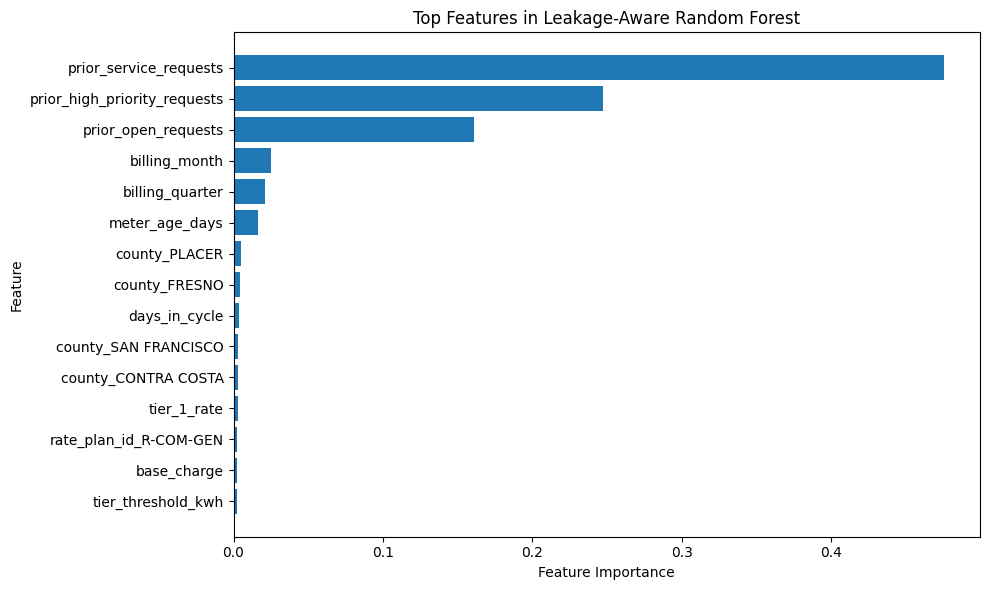

In [28]:
# Plot top 15 feature importances
top_n = 15
top_features = feature_importance.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features in Leakage-Aware Random Forest")
plt.tight_layout()
plt.show()

## 16. Generate Account-Cycle Exception Risk Scores

The leakage-aware Random Forest is used to score every account-cycle record.

The output includes:

- account and cycle identifiers
- account attributes
- prior service request indicators
- predicted exception risk
- risk band

Risk bands are percentile-based:

- High = top 15% of predicted risk scores
- Medium = next 35%
- Low = bottom 50%

This creates an operational risk queue that could be used by a billing operations team to prioritize review before billing exceptions occur.

In [29]:
# Score all account-cycle records using the selected leakage-aware random forest model
all_risk_proba = early_random_forest_model.predict_proba(X_early)[:, 1]

risk_scores = model_df.loc[modeling_data.index, [
    "account_id",
    "meter_id",
    "billing_cycle_id",
    "customer_segment",
    "county",
    "service_type",
    "rate_plan_id",
    "meter_type",
    "billing_month",
    "prior_service_requests",
    "prior_open_requests",
    "prior_in_progress_requests",
    "prior_high_priority_requests",
    "billing_exception_flag"
]].copy()

risk_scores["predicted_exception_risk"] = all_risk_proba

# Percentile-based risk bands
high_threshold = risk_scores["predicted_exception_risk"].quantile(0.85)
medium_threshold = risk_scores["predicted_exception_risk"].quantile(0.50)

risk_scores["risk_band"] = np.select(
    [
        risk_scores["predicted_exception_risk"] >= high_threshold,
        risk_scores["predicted_exception_risk"] >= medium_threshold
    ],
    [
        "High",
        "Medium"
    ],
    default="Low"
)

risk_scores = risk_scores.sort_values(
    "predicted_exception_risk",
    ascending=False
).reset_index(drop=True)

print("Risk score table shape:", risk_scores.shape)
print("\nRisk band distribution:")
print(risk_scores["risk_band"].value_counts())

risk_scores.head(20)

Risk score table shape: (60000, 16)

Risk band distribution:
risk_band
Low       30000
Medium    20995
High       9005
Name: count, dtype: int64


,account_id,meter_id,billing_cycle_id,customer_segment,county,service_type,rate_plan_id,meter_type,billing_month,prior_service_requests,prior_open_requests,prior_in_progress_requests,prior_high_priority_requests,billing_exception_flag,predicted_exception_risk,risk_band
0,ACCT003266,MTR003266,2024-07,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,7,5,3,0,3,1,0.949670,High
1,ACCT003266,MTR003266,2024-08,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,8,5,3,0,3,1,0.949430,High
2,ACCT003266,MTR003266,2024-09,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,9,5,3,0,3,1,0.948410,High
3,ACCT000264,MTR000264,2024-11,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,11,6,2,0,2,1,0.946735,High
4,ACCT003266,MTR003266,2024-06,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,6,4,3,0,2,1,0.946615,High
5,ACCT003008,MTR003008,2024-07,Residential,ALAMEDA,Electric,R-RES-TOU,Smart Meter,7,5,2,0,4,1,0.945806,High
6,ACCT000264,MTR000264,2024-07,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,7,5,1,0,2,1,0.945370,High
7,ACCT003136,MTR003136,2024-07,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,7,6,1,0,2,1,0.945311,High
8,ACCT003330,MTR003330,2024-09,Residential,KERN,Electric,R-RES-TOU,Smart Meter,9,4,2,0,2,1,0.945308,High
9,ACCT002389,MTR002389,2024-07,Residential,ALAMEDA,Electric,R-RES-TOU,Smart Meter,7,4,1,0,2,1,0.945285,High


In [30]:
# Evaluate actual exception rate by risk band
risk_band_summary = (
    risk_scores
    .groupby("risk_band")
    .agg(
        account_cycle_records=("account_id", "count"),
        actual_exceptions=("billing_exception_flag", "sum"),
        avg_predicted_risk=("predicted_exception_risk", "mean"),
        actual_exception_rate=("billing_exception_flag", "mean")
    )
    .reset_index()
)

risk_band_order = ["High", "Medium", "Low"]
risk_band_summary["risk_band"] = pd.Categorical(
    risk_band_summary["risk_band"],
    categories=risk_band_order,
    ordered=True
)

risk_band_summary = risk_band_summary.sort_values("risk_band")

risk_band_summary

,risk_band,account_cycle_records,actual_exceptions,avg_predicted_risk,actual_exception_rate
0,High,9005,3386,0.658043,0.376013
2,Medium,20995,1186,0.385325,0.056490
1,Low,30000,831,0.309073,0.027700


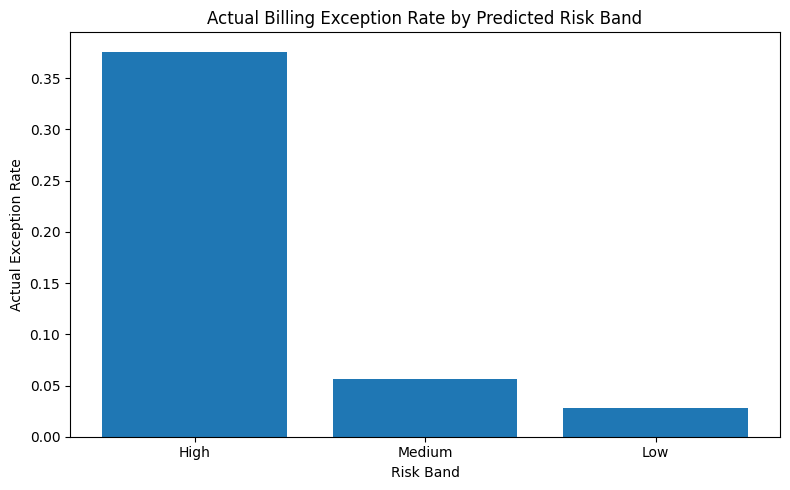

In [31]:
# Plot actual exception rate by risk band
plt.figure(figsize=(8, 5))
plt.bar(
    risk_band_summary["risk_band"].astype(str),
    risk_band_summary["actual_exception_rate"]
)

plt.xlabel("Risk Band")
plt.ylabel("Actual Exception Rate")
plt.title("Actual Billing Exception Rate by Predicted Risk Band")
plt.tight_layout()
plt.show()

In [32]:
# Export model outputs
risk_scores_output_path = ML_DIR / "account_cycle_exception_risk_scores.csv"
model_comparison_output_path = ML_DIR / "model_comparison.csv"
feature_importance_output_path = ML_DIR / "feature_importance.csv"
risk_band_summary_output_path = ML_DIR / "risk_band_summary.csv"

risk_scores.to_csv(risk_scores_output_path, index=False)
model_comparison_rounded.to_csv(model_comparison_output_path, index=False)
feature_importance.to_csv(feature_importance_output_path, index=False)
risk_band_summary.to_csv(risk_band_summary_output_path, index=False)

print("ML outputs exported:")
print(risk_scores_output_path)
print(model_comparison_output_path)
print(feature_importance_output_path)
print(risk_band_summary_output_path)

ML outputs exported:
..\data\ml\account_cycle_exception_risk_scores.csv
..\data\ml\model_comparison.csv
..\data\ml\feature_importance.csv
..\data\ml\risk_band_summary.csv


## 17. Risk Band Interpretation

The leakage-aware Random Forest model separates account-cycle records into meaningful operational risk bands.

The high-risk band contains the top 15% of scored account-cycle records and has a substantially higher actual billing exception rate than the medium- and low-risk bands.

This means the model could be used as a pre-billing review queue. Instead of reviewing all accounts equally, a billing operations team could prioritize accounts with the highest predicted exception risk.

In [33]:
# Calculate risk lift versus low-risk group
low_rate = risk_band_summary.loc[
    risk_band_summary["risk_band"] == "Low",
    "actual_exception_rate"
].iloc[0]

risk_band_summary["lift_vs_low_risk"] = (
    risk_band_summary["actual_exception_rate"] / low_rate
)

risk_band_summary_rounded = risk_band_summary.copy()

for col in ["avg_predicted_risk", "actual_exception_rate", "lift_vs_low_risk"]:
    risk_band_summary_rounded[col] = risk_band_summary_rounded[col].round(4)

risk_band_summary_rounded

,risk_band,account_cycle_records,actual_exceptions,avg_predicted_risk,actual_exception_rate,lift_vs_low_risk
0,High,9005,3386,0.6580,0.3760,13.5745
2,Medium,20995,1186,0.3853,0.0565,2.0393
1,Low,30000,831,0.3091,0.0277,1.0000


In [34]:
# Export updated risk band summary with lift calculation
risk_band_summary_lift_output_path = ML_DIR / "risk_band_summary_with_lift.csv"

risk_band_summary_rounded.to_csv(risk_band_summary_lift_output_path, index=False)

print("Updated risk band summary exported:")
print(risk_band_summary_lift_output_path)

Updated risk band summary exported:
..\data\ml\risk_band_summary_with_lift.csv


## 18. Top High-Risk Account-Cycle Records

The table below shows the highest-risk account-cycle records according to the leakage-aware Random Forest model.

In a real utility operations workflow, this type of output could support targeted review before billing exceptions occur.

In [35]:
top_risk_records = risk_scores.head(25).copy()

top_risk_records[
    [
        "account_id",
        "meter_id",
        "billing_cycle_id",
        "customer_segment",
        "county",
        "service_type",
        "rate_plan_id",
        "meter_type",
        "prior_service_requests",
        "prior_open_requests",
        "prior_high_priority_requests",
        "predicted_exception_risk",
        "risk_band",
        "billing_exception_flag"
    ]
]

,account_id,meter_id,billing_cycle_id,customer_segment,county,service_type,rate_plan_id,meter_type,prior_service_requests,prior_open_requests,prior_high_priority_requests,predicted_exception_risk,risk_band,billing_exception_flag
0,ACCT003266,MTR003266,2024-07,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,5,3,3,0.949670,High,1
1,ACCT003266,MTR003266,2024-08,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,5,3,3,0.949430,High,1
2,ACCT003266,MTR003266,2024-09,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,5,3,3,0.948410,High,1
3,ACCT000264,MTR000264,2024-11,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,6,2,2,0.946735,High,1
4,ACCT003266,MTR003266,2024-06,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,4,3,2,0.946615,High,1
5,ACCT003008,MTR003008,2024-07,Residential,ALAMEDA,Electric,R-RES-TOU,Smart Meter,5,2,4,0.945806,High,1
6,ACCT000264,MTR000264,2024-07,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,5,1,2,0.945370,High,1
7,ACCT003136,MTR003136,2024-07,Residential,CONTRA COSTA,Electric,R-RES-TOU,Smart Meter,6,1,2,0.945311,High,1
8,ACCT003330,MTR003330,2024-09,Residential,KERN,Electric,R-RES-TOU,Smart Meter,4,2,2,0.945308,High,1
9,ACCT002389,MTR002389,2024-07,Residential,ALAMEDA,Electric,R-RES-TOU,Smart Meter,4,1,2,0.945285,High,1


## 19. Notebook Summary

This notebook added a predictive analytics layer to the PG&E-style Utility Operations and Meter-to-Cash Analytics project.

Key outcomes:

- Built an account-cycle-level modeling dataset with 60,000 records.
- Created a billing exception target with a 9% exception rate.
- Identified and addressed leakage from deterministic operational trigger fields.
- Trained leakage-aware logistic regression and random forest models.
- Selected the leakage-aware Random Forest model for risk scoring.
- Exported account-cycle risk scores, feature importance, model comparison, and risk band summaries.

The final model supports a practical utility operations use case: prioritizing account-cycle records for review before billing exceptions occur.